# ImageCLEFmed Concept Detection Task: Exploratory Data Analysis

## Import Libraries and Load Dataset

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import combinations
from wordcloud import WordCloud
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms, models
import torch
from PIL import Image
from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.gridspec as gridspec

In [ ]:
!cp "/content/drive/MyDrive/dev_concept_with_mapping.zip" "/content/"

!unzip -q "/content/dev_concept_with_mapping.zip" -d "/content/dev_concept_with_mapping"

In [ ]:
dataset_path = '/content/dev_concept_with_mapping/dev_concept'

## Initialize Dataset Class and Load Dataframes

In [ ]:
class ImageCLEFmedDataset(Dataset):
    def __init__(self, root_dir, mlb, split='train', transform=None, exclude_ids=None):
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        self.mlb = mlb

        self.image_dir = os.path.join(root_dir, 'images')

        cui_path = os.path.join(root_dir, 'cui_mapping.csv')
        self.cui_mapping = {}
        if os.path.exists(cui_path):
            cui_df = pd.read_csv(cui_path)
            self.cui_mapping = dict(zip(cui_df['CUI'], cui_df['Canonical name']))

        if split == 'test':
            test_path = os.path.join(root_dir, 'test_concepts.csv')
            self.data_df = pd.read_csv(test_path).reset_index(drop=True)
        else:
            concepts_path = os.path.join(root_dir, 'concepts.csv')
            all_concepts_df = pd.read_csv(concepts_path)
            self.data_df = all_concepts_df[
                all_concepts_df['ID'].str.contains(self.split, case=False, na=False)
            ].reset_index(drop=True)

            if split == 'train' and exclude_ids is not None:
                before = len(self.data_df)
                self.data_df = self.data_df[
                    ~self.data_df['ID'].isin(exclude_ids)
                ].reset_index(drop=True)

    def __len__(self):
        return len(self.data_df)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        row = self.data_df.iloc[idx]
        img_id = row['ID']

        cui_string = row['CUIs']
        cuis = str(cui_string).split(';') if pd.notna(cui_string) else []

        concept_names = [self.cui_mapping.get(cui, cui) for cui in cuis]

        img_name = os.path.join(self.image_dir, f"{img_id}.jpg")

        image = Image.open(img_name).convert('RGB')

        if self.transform:
            image = self.transform(image)

        binary_labels = self.mlb.transform([cuis])[0]
        label_tensor = torch.tensor(binary_labels, dtype=torch.float32)

        return {
            'id': img_id,
            'image': image,
            'labels': label_tensor,
            'cuis': ";".join(cuis),
            'concept_names': ";".join(concept_names)
        }

In [ ]:
dataset_path = '/content/dev_concept_with_mapping/dev_concept'

all_concepts_df = pd.read_csv(f'{dataset_path}/concepts.csv')

test_concepts_df = pd.read_csv(f'{dataset_path}/test_concepts.csv')
test_ids = set(test_concepts_df['ID'].tolist())

train_concepts_df = all_concepts_df[
    all_concepts_df['ID'].str.contains('train', case=False, na=False) &
    ~all_concepts_df['ID'].isin(test_ids)
].reset_index(drop=True)

all_train_cuis = train_concepts_df['CUIs'].dropna().apply(lambda x: str(x).split(';')).tolist()

mlb = MultiLabelBinarizer()
mlb.fit(all_train_cuis)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_train_dataset = ImageCLEFmedDataset(dataset_path, mlb, split='train', transform=transform)
train_dataset = ImageCLEFmedDataset(dataset_path, mlb, split='train', transform=transform, exclude_ids=test_ids)
val_dataset   = ImageCLEFmedDataset(dataset_path, mlb, split='valid', transform=transform)
test_dataset  = ImageCLEFmedDataset(dataset_path, mlb, split='test',  transform=transform)

In [ ]:
all_concepts = pd.read_csv(f'{dataset_path}/concepts.csv')
train_concepts = all_concepts[all_concepts['ID'].str.contains('train', case=False, na=False)]
valid_concepts = all_concepts[all_concepts['ID'].str.contains('valid', case=False, na=False)]

cui_mapping = pd.read_csv(f'{dataset_path}/cui_mapping.csv')
cui_dict = dict(zip(cui_mapping['CUI'], cui_mapping['Canonical name']))

In [ ]:
print("Initial ImageCLEFmed split:")
print(f" -Train samples : {len(full_train_dataset)}")
print(f" -Val samples   : {len(val_dataset)}")
print("\nOur stratified re-splitting:")
print(f" -Train samples : {len(train_dataset)}")
print(f" -Val samples   : {len(val_dataset)}")
print(f" -Test samples  : {len(test_dataset)}")
print(f"\nTotal samples : {len(all_concepts)} samples")

Initial ImageCLEFmed split:
 -Train samples : 97364
 -Val samples   : 19240

Our stratified re-splitting:
 -Train samples : 90359
 -Val samples   : 19240
 -Test samples  : 7005

Total samples : 116604 samples


## Exploratory Data Analysis

### Dataset Inspection

In [ ]:
all_concepts.head()

,ID,CUIs
0,ImageCLEFmedical_Caption_2026_train_0,C0040405
1,ImageCLEFmedical_Caption_2026_train_1,C1306645;C0817096;C0442800;C0018787;C0242073
2,ImageCLEFmedical_Caption_2026_train_2,C0040405;C0856747
3,ImageCLEFmedical_Caption_2026_train_3,C0041618
4,ImageCLEFmedical_Caption_2026_train_4,C0040405;C0040053


In [ ]:
all_concepts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116604 entries, 0 to 116603
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   ID      116604 non-null  object
 1   CUIs    116604 non-null  object
dtypes: object(2)
memory usage: 1.8+ MB


In [ ]:
all_concepts["CUI_List"] = all_concepts["CUIs"].str.split(";")

all_cuis = [cui for sublist in all_concepts["CUI_List"] for cui in sublist]
cui_counts = Counter(all_cuis)

print(f"Total unique CUIs: {len(cui_counts)}")

Total unique CUIs: 2646


### Most Common CUIs

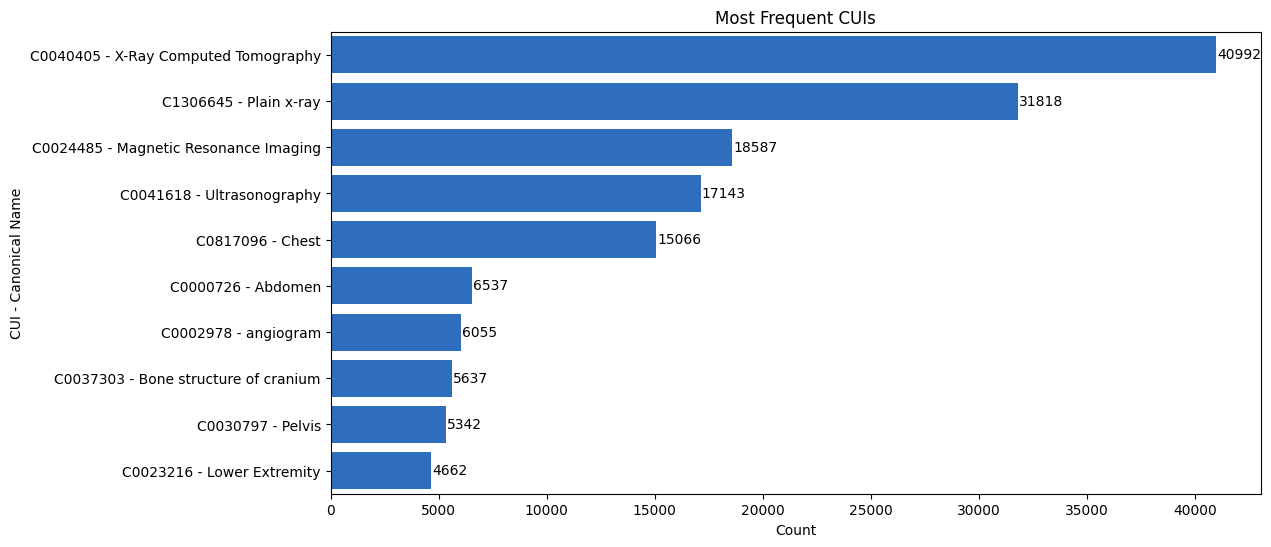

In [ ]:
top_cuis = cui_counts.most_common(10)
top_cui_labels, top_cui_values = zip(*top_cuis)

combined_labels = [f"{cui} - {cui_dict.get(cui, 'Unknown Name')}" for cui in top_cui_labels]

plt.figure(figsize=(12, 6))

ax = sns.barplot(x=list(top_cui_values), y=combined_labels, color='#176BD7')

for i, value in enumerate(top_cui_values):
    ax.text(value + max(top_cui_values) * 1e-3, i, str(value), va='center')

plt.xlabel("Count")
plt.ylabel("CUI - Canonical Name")
plt.title("Most Frequent CUIs")

plt.show()

### Rare CUIs

In [ ]:
single_occurrence_cuis = [cui for cui, count in cui_counts.items() if count == 1]

rare_cui_data = [
    {
        "CUI": cui,
        "Canonical Name": cui_dict.get(cui, "Unknown Name"),
        "Count": 1
    }
    for cui in single_occurrence_cuis
]

rare_cui_df = pd.DataFrame(rare_cui_data)

print(f"Total CUIs appearing exactly once: {len(rare_cui_df)}")

rare_cui_df.head(10)

Total CUIs appearing exactly once: 10


,CUI,Canonical Name,Count
0,C1962945,Radiographic imaging procedure,1
1,C1690005,MRI venography,1
2,C0243032,Magnetic Resonance Angiography,1
3,C1956110,Cone-Beam Computed Tomography,1
4,C0412650,Computed tomography of cervical spine,1
5,C0011906,Differential Diagnosis,1
6,C0202657,CT follow-up,1
7,C0203668,Radioisotope scan of bone,1
8,C0040395,tomography,1
9,C0598801,Diffusion weighted imaging,1


### CUIs per Image Distribution

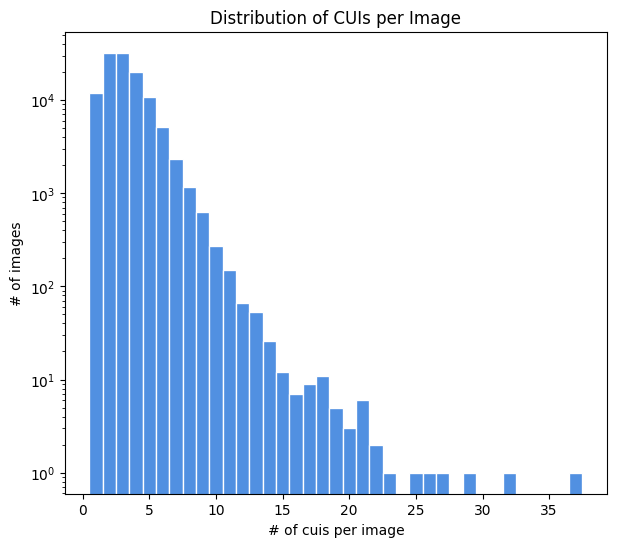

In [ ]:
all_concepts['CUI_Count'] = all_concepts['CUI_List'].apply(len)

plt.figure(figsize=(7, 6))

ax = sns.histplot(data=all_concepts, x='CUI_Count', discrete=True, color='#176BD7', edgecolor='white')

ax.set_yscale('log')

plt.xlabel("# of cuis per image")
plt.ylabel("# of images")
plt.title("Distribution of CUIs per Image")

plt.show()

In [ ]:
images_with_single_concept = all_concepts[all_concepts['CUI_Count'] == 1]
print(f"Number of images with exactly one concept: {len(images_with_single_concept)}")

Number of images with exactly one concept: 11814


In [ ]:
average_cui_count = all_concepts['CUI_Count'].mean()
print(f"Average number of CUIs per image: {average_cui_count:.2f}")

Average number of CUIs per image: 3.22


### CUI Co-occurrence Analysis

In [ ]:
def format_combo(combo_tuple):
    return " | ".join([f"{cui} ({cui_dict.get(cui, 'Unknown')})" for cui in combo_tuple])

pairs_counter = Counter()
triplets_counter = Counter()
combo_4plus_counter = Counter()

for cuis in all_concepts['CUI_List']:
    unique_cuis = sorted(set(cuis))
    n = len(unique_cuis)

    if n >= 2:
        pairs_counter.update(combinations(unique_cuis, 2))

    if n >= 3:
        triplets_counter.update(combinations(unique_cuis, 3))

    if n >= 4:
        max_combo_size = min(n + 1, 7)

        for k in range(4, max_combo_size):
            combo_4plus_counter.update(combinations(unique_cuis, k))

def create_combo_df(counter_obj, name="Combination"):
    top_items = counter_obj.most_common(10)
    data = [
        {name: format_combo(combo), "Size": len(combo), "Count": count}
        for combo, count in top_items
    ]
    return pd.DataFrame(data)

df_pairs = create_combo_df(pairs_counter, "CUI Pair (2)")
df_triplets = create_combo_df(triplets_counter, "CUI Triplet (3)")
df_4plus = create_combo_df(combo_4plus_counter, "CUI Set (4+)")

pd.set_option('display.max_colwidth', None)

print("=== Top 10 Most Frequent CUI Pairs ===")
display(df_pairs)

print("\n=== Top 10 Most Frequent CUI Triplets ===")
display(df_triplets)

print("\n=== Top 10 Most Frequent CUI Sets (4 or more) ===")
display(df_4plus)

=== Top 10 Most Frequent CUI Pairs ===


,CUI Pair (2),Size,Count
0,C0817096 (Chest) | C1306645 (Plain x-ray),2,11156
1,C0037303 (Bone structure of cranium) | C1306645 (Plain x-ray),2,5456
2,C0023216 (Lower Extremity) | C1306645 (Plain x-ray),2,4582
3,C0000726 (Abdomen) | C1306645 (Plain x-ray),2,3592
4,C0040405 (X-Ray Computed Tomography) | C0817096 (Chest),2,3518
5,C0000726 (Abdomen) | C0040405 (X-Ray Computed Tomography),2,2556
6,C0030797 (Pelvis) | C1306645 (Plain x-ray),2,2347
7,C0030797 (Pelvis) | C0040405 (X-Ray Computed Tomography),2,2234
8,C1140618 (Upper Extremity) | C1306645 (Plain x-ray),2,2205
9,C0037949 (Vertebral column) | C1306645 (Plain x-ray),2,1922



=== Top 10 Most Frequent CUI Triplets ===


,CUI Triplet (3),Size,Count
0,C0000726 (Abdomen) | C0030797 (Pelvis) | C0040405 (X-Ray Computed Tomography),3,870
1,C0032227 (Pleural effusion disorder) | C0817096 (Chest) | C1306645 (Plain x-ray),3,801
2,C0024687 (Mandible) | C0037303 (Bone structure of cranium) | C1306645 (Plain x-ray),3,721
3,C0018787 (Heart) | C0817096 (Chest) | C1306645 (Plain x-ray),3,527
4,C0041618 (Ultrasonography) | C0225883 (Right ventricular structure) | C0225897 (Left ventricular structure),3,522
5,C0015811 (Femur) | C0023216 (Lower Extremity) | C1306645 (Plain x-ray),3,504
6,C0032326 (Pneumothorax) | C0817096 (Chest) | C1306645 (Plain x-ray),3,480
7,C0011443 (Dentition) | C0037303 (Bone structure of cranium) | C1306645 (Plain x-ray),3,432
8,C0225759 (Lung field) | C0817096 (Chest) | C1306645 (Plain x-ray),3,388
9,C0024947 (Maxilla) | C0037303 (Bone structure of cranium) | C1306645 (Plain x-ray),3,376



=== Top 10 Most Frequent CUI Sets (4 or more) ===


,CUI Set (4+),Size,Count
0,C0041618 (Ultrasonography) | C0225883 (Right ventricular structure) | C0225897 (Left ventricular structure) | C1269894 (Entire left atrium),4,176
1,C0041618 (Ultrasonography) | C0225860 (Left atrial structure) | C0225883 (Right ventricular structure) | C0225897 (Left ventricular structure),4,175
2,C0041618 (Ultrasonography) | C0225883 (Right ventricular structure) | C0225897 (Left ventricular structure) | C1269890 (Entire right atrium),4,141
3,C0041618 (Ultrasonography) | C0225844 (Right atrial structure) | C0225883 (Right ventricular structure) | C0225897 (Left ventricular structure),4,138
4,C0225844 (Right atrial structure) | C0225860 (Left atrial structure) | C0225883 (Right ventricular structure) | C0225897 (Left ventricular structure),4,138
5,C0041618 (Ultrasonography) | C0225883 (Right ventricular structure) | C1269890 (Entire right atrium) | C1269894 (Entire left atrium),4,137
6,C0225883 (Right ventricular structure) | C0225897 (Left ventricular structure) | C1269890 (Entire right atrium) | C1269894 (Entire left atrium),4,136
7,C0041618 (Ultrasonography) | C0225844 (Right atrial structure) | C0225860 (Left atrial structure) | C0225883 (Right ventricular structure),4,133
8,C0041618 (Ultrasonography) | C0225897 (Left ventricular structure) | C1269890 (Entire right atrium) | C1269894 (Entire left atrium),4,127
9,C0041618 (Ultrasonography) | C0225844 (Right atrial structure) | C0225860 (Left atrial structure) | C0225897 (Left ventricular structure),4,126


### Long Tail Distribution

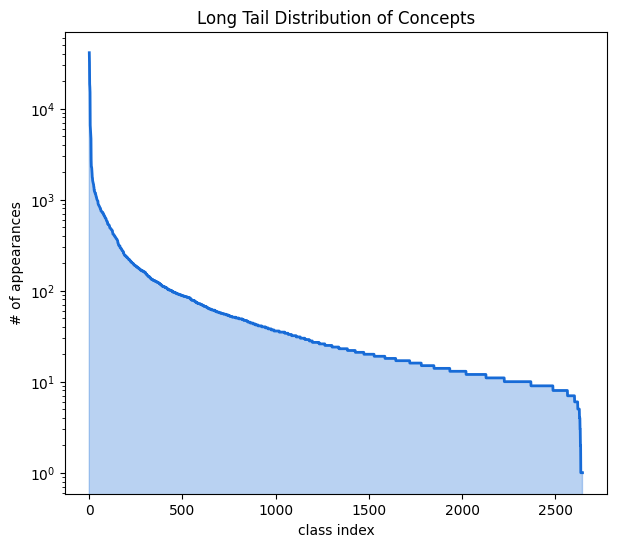

In [ ]:
frequencies = sorted(cui_counts.values(), reverse=True)

ranks = np.arange(1, len(frequencies) + 1)

plt.figure(figsize=(7, 6))

plt.plot(ranks, frequencies, color='#176BD7', linewidth=2)
plt.fill_between(ranks, frequencies, color='#176BD7', alpha=0.3)

plt.yscale('log')

plt.xlabel('class index')
plt.ylabel('# of appearances')
plt.title('Long Tail Distribution of Concepts')

plt.show()

### Top 15 Concepts: Train vs Validation Distribution

/tmp/ipykernel_2391/517660576.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_concepts.loc[:, "CUI_List"] = train_concepts["CUIs"].str.split(";")
/tmp/ipykernel_2391/517660576.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_concepts.loc[:, "CUI_List"] = valid_concepts["CUIs"].str.split(";")


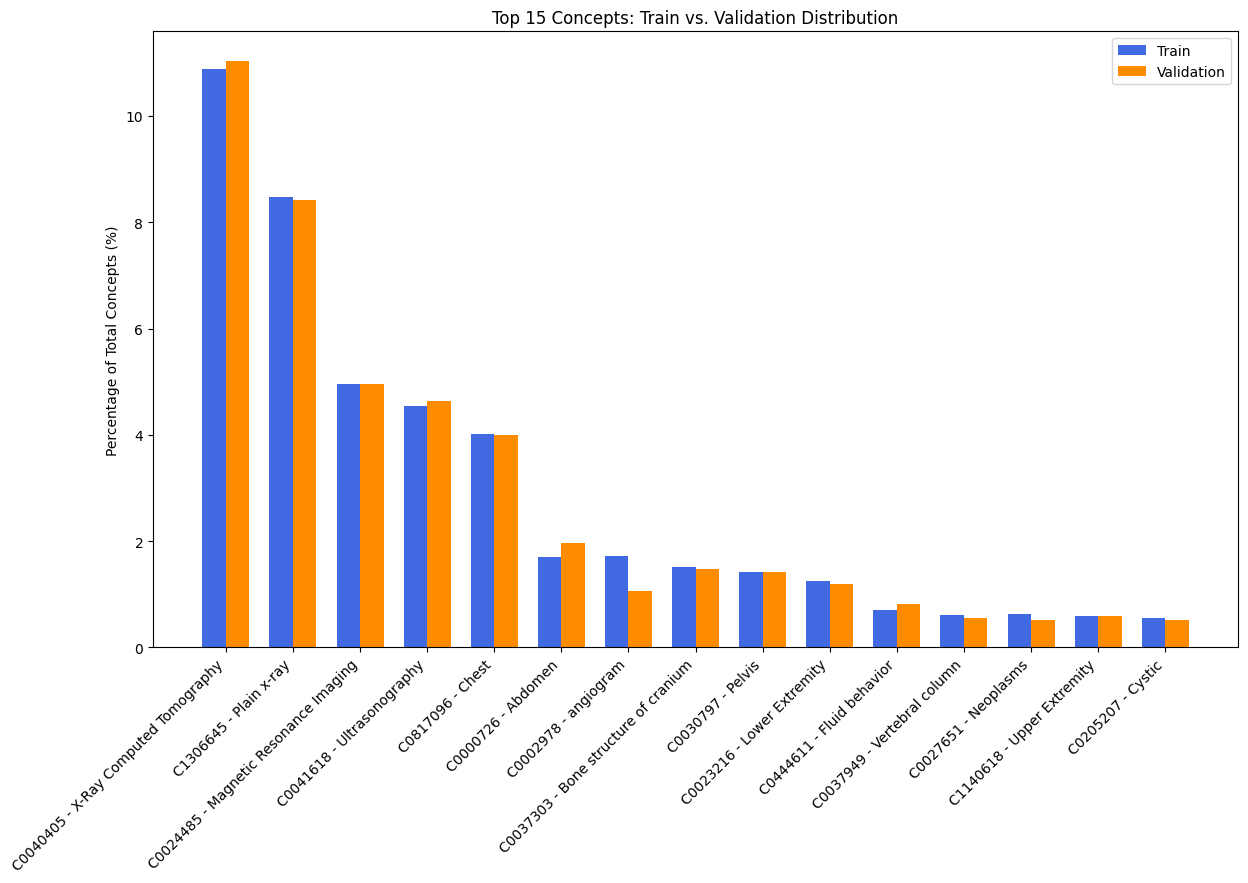

In [ ]:
train_concepts.loc[:, "CUI_List"] = train_concepts["CUIs"].str.split(";")
valid_concepts.loc[:, "CUI_List"] = valid_concepts["CUIs"].str.split(";")

top_15_cuis = [cui for cui, count in cui_counts.most_common(15)]
top_15_names = [f"{cui} - {cui_dict.get(cui, 'Unknown')}" for cui in top_15_cuis]

train_counts = Counter(cui for sublist in train_concepts["CUI_List"].dropna() for cui in sublist)
valid_counts = Counter(cui for sublist in valid_concepts["CUI_List"].dropna() for cui in sublist)

train_total = sum(train_counts.values())
valid_total = sum(valid_counts.values())

train_pcts = [(train_counts.get(cui, 0) / train_total) * 100 for cui in top_15_cuis]
valid_pcts = [(valid_counts.get(cui, 0) / valid_total) * 100 for cui in top_15_cuis]

x = np.arange(len(top_15_names))
width = 0.35

plt.figure(figsize=(14, 8))
plt.bar(x - width/2, train_pcts, width, label='Train', color='royalblue')
plt.bar(x + width/2, valid_pcts, width, label='Validation', color='darkorange')

plt.ylabel('Percentage of Total Concepts (%)')
plt.title('Top 15 Concepts: Train vs. Validation Distribution')
plt.xticks(x, top_15_names, rotation=45, ha='right')
plt.legend()

plt.show()

### Co-occurrence Heatmap of Top 15 Concepts

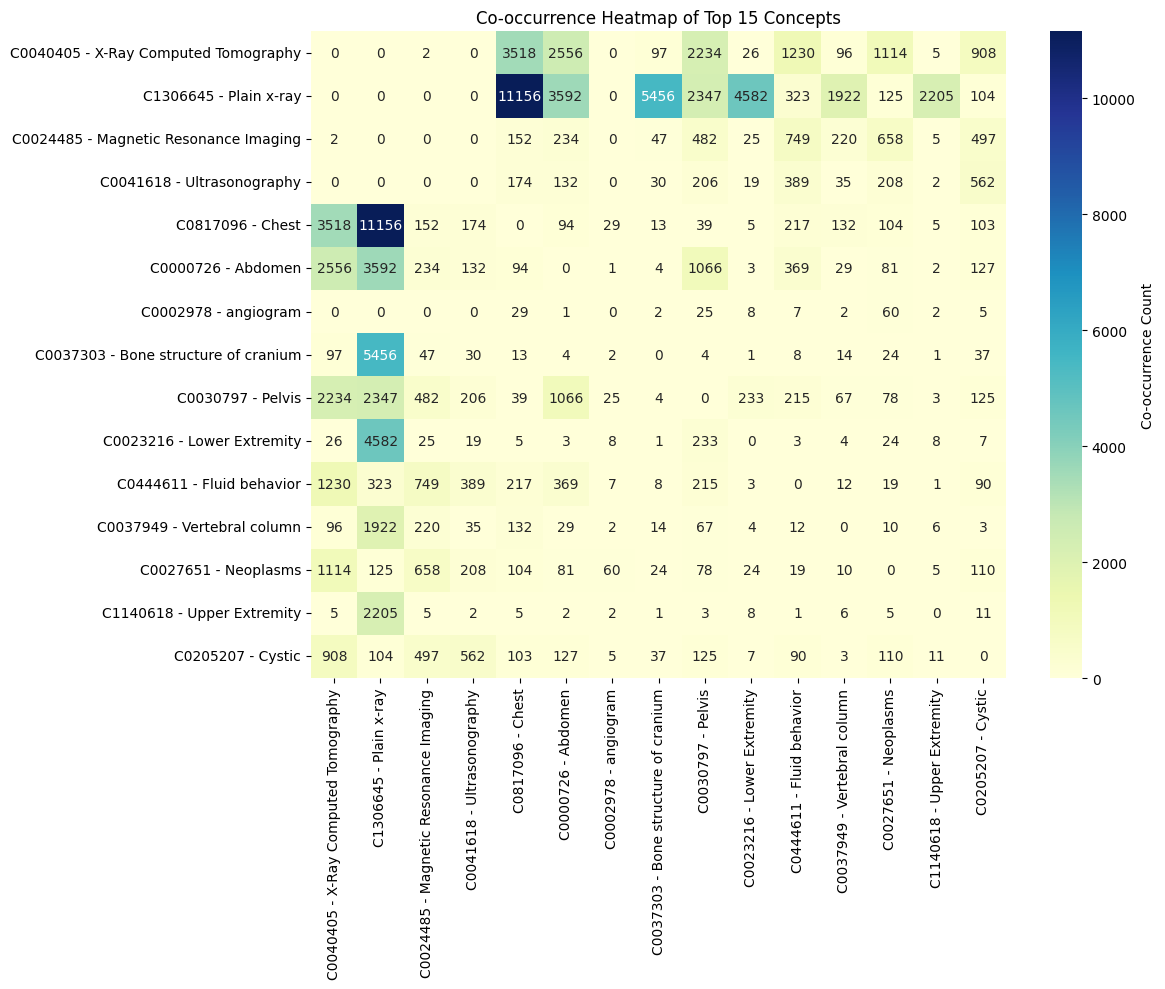

In [ ]:
heatmap_data = pd.DataFrame(0, index=top_15_names, columns=top_15_names)

for cuis in all_concepts['CUI_List'].dropna():
    present_top_cuis = [cui for cui in set(cuis) if cui in top_15_cuis]

    present_names = [f"{cui} - {cui_dict.get(cui, 'Unknown')}" for cui in present_top_cuis]

    for c1, c2 in combinations(present_names, 2):
        heatmap_data.loc[c1, c2] += 1
        heatmap_data.loc[c2, c1] += 1

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu",
            cbar_kws={'label': 'Co-occurrence Count'})

plt.title("Co-occurrence Heatmap of Top 15 Concepts")
plt.tight_layout()
plt.show()

### Word Cloud of Concept Names

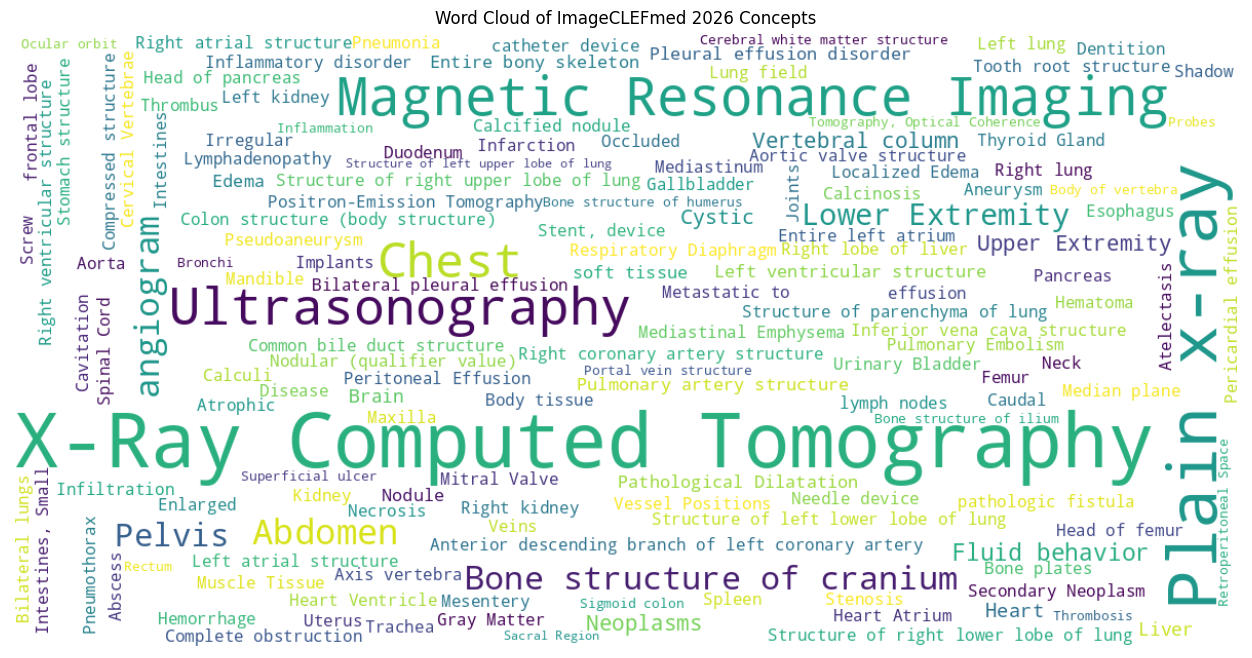

In [ ]:
name_frequencies = {cui_dict.get(cui, "Unknown"): count for cui, count in cui_counts.items()}

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis',
    max_words=150
).generate_from_frequencies(name_frequencies)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of ImageCLEFmed 2026 Concepts")
plt.show()

### Distribution after Stratified Split

In [ ]:
def label_frequency(dataset):
    cui_series = dataset.data_df['CUIs'].fillna('')

    cuis_list = [cui_str.split(';') if cui_str else [] for cui_str in cui_series]

    all_labels = dataset.mlb.transform(cuis_list)

    return all_labels.mean(axis=0)

train_freq = label_frequency(train_dataset)
test_freq  = label_frequency(test_dataset)

correlation = np.corrcoef(train_freq, test_freq)[0, 1]
print(f"Label distribution correlation (train vs test): {correlation:.4f}")

Label distribution correlation (train vs test): 0.9999


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['C1956110'] will be ignored
  warnings.warn(


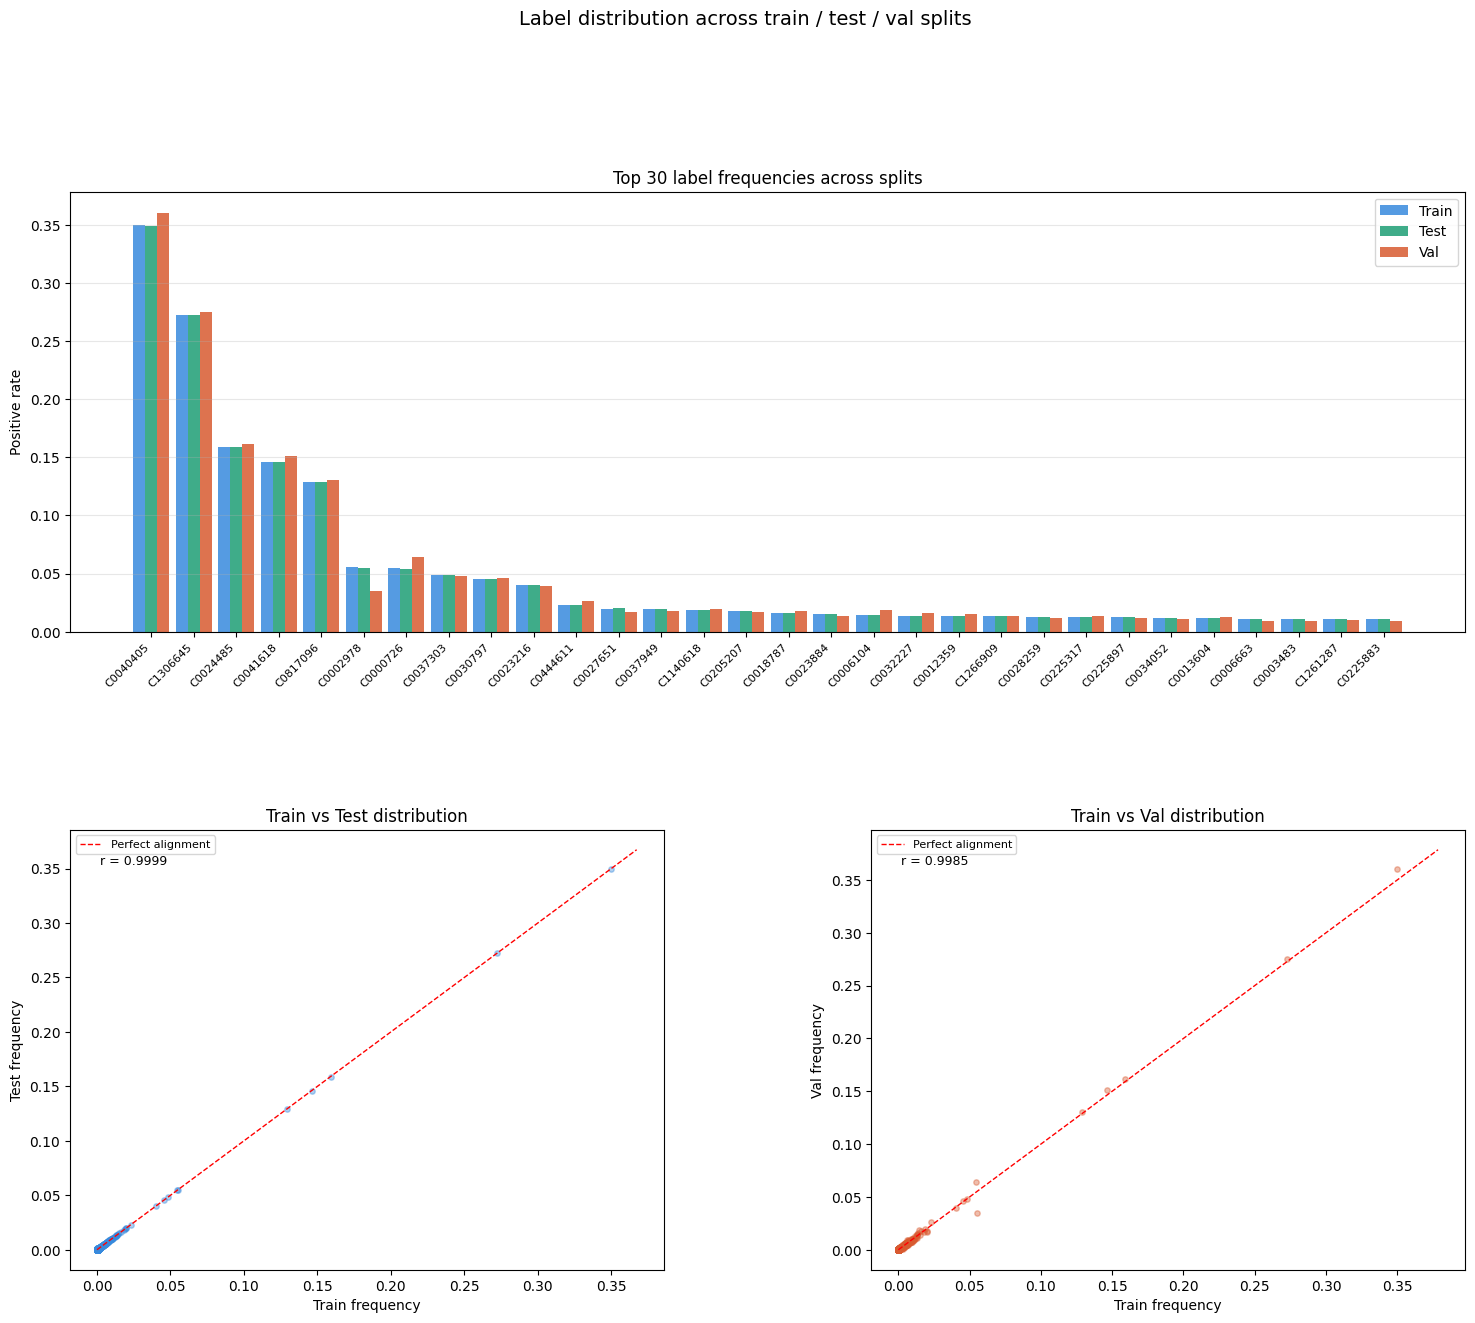

In [ ]:
def get_fast_label_freq(dataset):
    cui_series = dataset.data_df['CUIs'].fillna('')
    cuis_list = [cui_str.split(';') if cui_str else [] for cui_str in cui_series]
    all_labels = dataset.mlb.transform(cuis_list)
    return all_labels.mean(axis=0)

train_freq = get_fast_label_freq(train_dataset)
test_freq  = get_fast_label_freq(test_dataset)
val_freq   = get_fast_label_freq(val_dataset)

TOP_N = 30
top_idx = np.argsort(train_freq)[-TOP_N:][::-1]
labels  = [mlb.classes_[i] for i in top_idx]

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
x = np.arange(TOP_N)
w = 0.28
ax1.bar(x - w, train_freq[top_idx], w, label='Train', color='#378ADD', alpha=0.85)
ax1.bar(x,      test_freq[top_idx],  w, label='Test',  color='#1D9E75', alpha=0.85)
ax1.bar(x + w,  val_freq[top_idx],   w, label='Val',   color='#D85A30', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Positive rate')
ax1.set_title(f'Top {TOP_N} label frequencies across splits')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(train_freq, test_freq, alpha=0.4, s=15, color='#378ADD')
lim = max(train_freq.max(), test_freq.max()) * 1.05
ax2.plot([0, lim], [0, lim], 'r--', lw=1, label='Perfect alignment')
ax2.set_xlabel('Train frequency')
ax2.set_ylabel('Test frequency')
ax2.set_title('Train vs Test distribution')
ax2.legend(fontsize=8)
corr = np.corrcoef(train_freq, test_freq)[0, 1]
ax2.text(0.05, 0.92, f'r = {corr:.4f}', transform=ax2.transAxes, fontsize=9)

ax3 = fig.add_subplot(gs[1, 1])
ax3.scatter(train_freq, val_freq, alpha=0.4, s=15, color='#D85A30')
lim = max(train_freq.max(), val_freq.max()) * 1.05
ax3.plot([0, lim], [0, lim], 'r--', lw=1, label='Perfect alignment')
ax3.set_xlabel('Train frequency')
ax3.set_ylabel('Val frequency')
ax3.set_title('Train vs Val distribution')
ax3.legend(fontsize=8)
corr_val = np.corrcoef(train_freq, val_freq)[0, 1]
ax3.text(0.05, 0.92, f'r = {corr_val:.4f}', transform=ax3.transAxes, fontsize=9)

plt.suptitle('Label distribution across train / test / val splits', fontsize=14, y=1.01)
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()